# Section 1: Setup & Data Loading

In [53]:
# Loading Libraries / Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [54]:
# Loading the Dataset
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/nvidia-stock-data-19992026-the-ai-mega-stock/nvidia_stock_data_1999_2026.csv")

# Convert Date column to datetime formart
df['date'] = pd.to_datetime(df['date'])

# Sorting by date (oldest to newest)
df = df.sort_values('date').reset_index(drop=True)

# First look
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(7079, 16)
        date    open    high     low   close    volume  shares_outstanding_bn  \
0 1999-01-22  0.0314  0.0315  0.0312  0.0313   4156178                  0.600   
1 1999-01-25  0.0310  0.0317  0.0308  0.0313  17362290                  0.614   
2 1999-01-26  0.0315  0.0318  0.0312  0.0315  10531814                  0.612   
3 1999-01-27  0.0315  0.0319  0.0309  0.0314  14602646                  0.618   
4 1999-01-28  0.0313  0.0315  0.0313  0.0314  19343208                  0.602   

   market_cap_usd_bn  quarterly_revenue_usd_bn  sma_20  sma_50  sma_200  \
0               0.02                      1.33  0.0317  0.0294   0.0312   
1               0.02                      1.92  0.0312  0.0333   0.0349   
2               0.02                      2.17  0.0327  0.0299   0.0359   
3               0.02                      1.00  0.0309  0.0293   0.0292   
4               0.02                      1.53  0.0305  0.0294   0.0327   

   rsi_14  stock_split          era           key_e

# Section 2: EDA

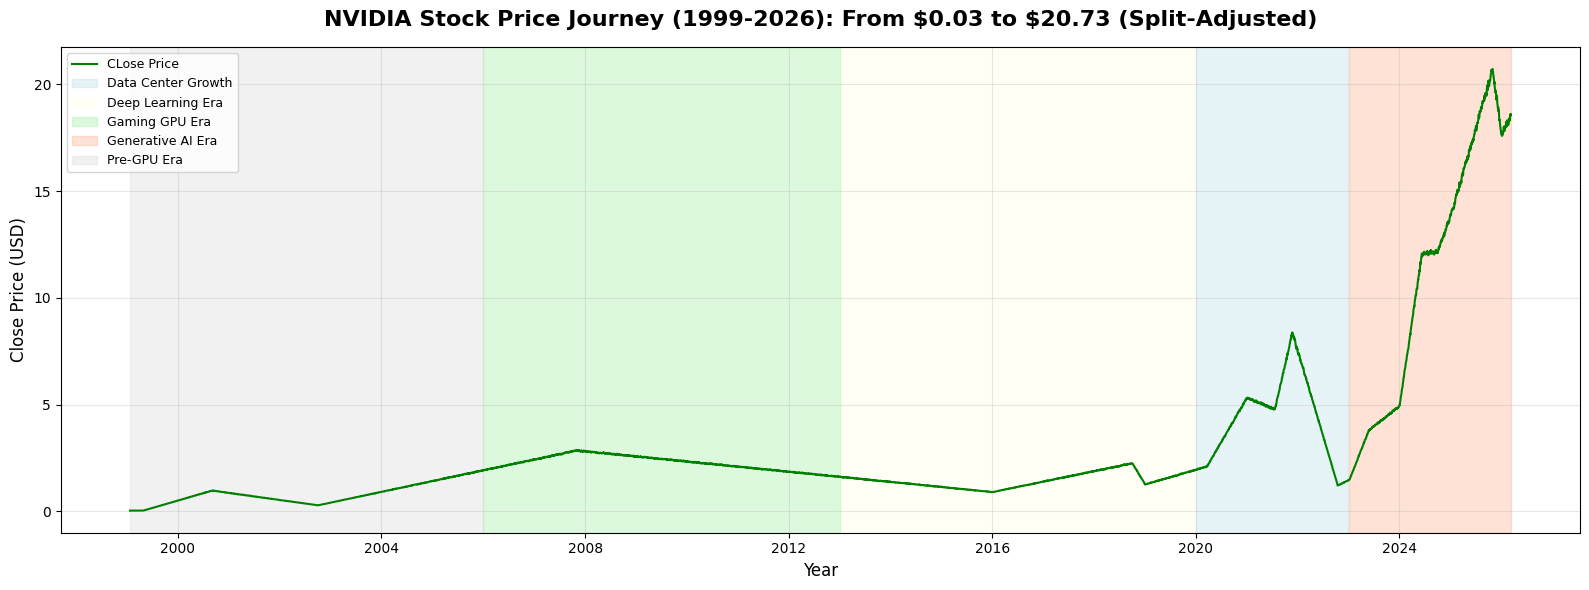

In [55]:
# Plot 1: NVIDIA Full Price Journey (1999-2026)
fig, ax = plt.subplots(figsize=(16,6))

# Plot the closing price line
ax.plot(df['date'], df['close'], color='green', linewidth=1.5, label='CLose Price')

# Era shading - Defining era regions with colors
era_colors= {
    'Pre-GPU Era' : 'lightgrey',
    'Gaming GPU Era' : 'lightgreen',
    'Deep Learning Era' : 'lightyellow',
    'Data Center Growth' : 'lightblue',
    'Generative AI Era' : 'lightsalmon'
}

eras = df.groupby('era')['date'].agg(['min', 'max'])

for era_name, row in eras.iterrows():
    color = era_colors.get(era_name, 'whitesmoke')
    ax.axvspan(row['min'], row['max'], alpha=0.3, color=color, label=era_name)


# Labels
ax.set_title('NVIDIA Stock Price Journey (1999-2026): From \$0.03 to \$20.73 (Split-Adjusted)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Close Price (USD)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Split Adjusted means tthe dataset goes back in time and divides all old prices to make them comparable on the same scale.
# So a price of $5 in 2020 and $5 in 2005 are truly comparable.

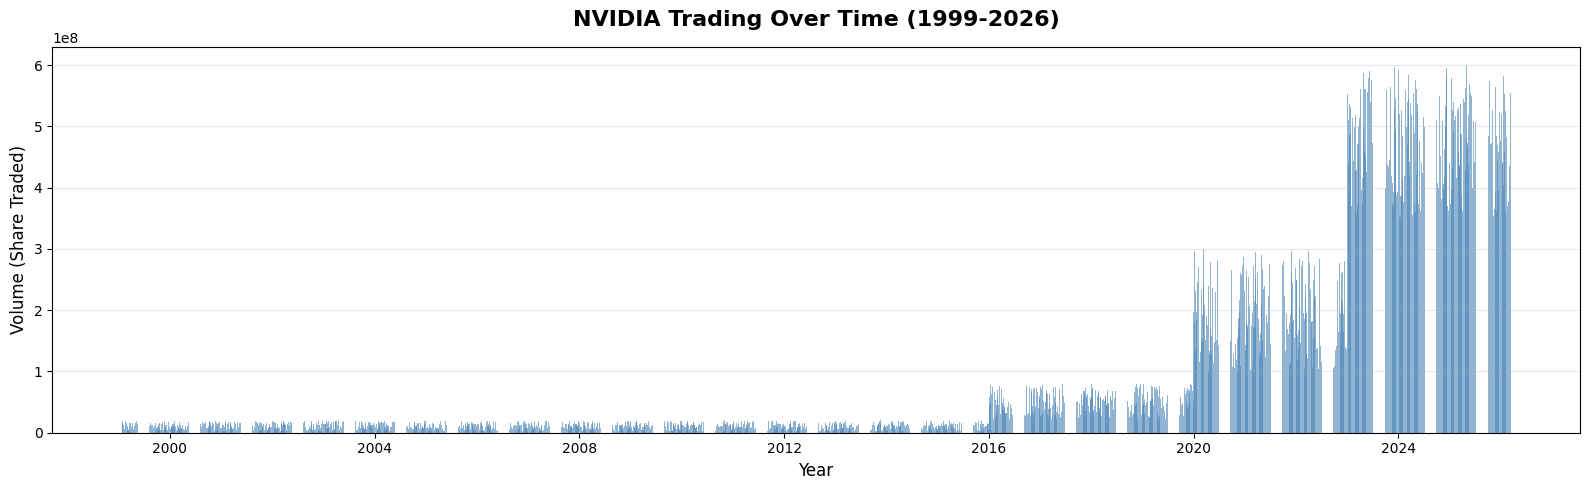

In [56]:
# Plot 2: Volume Over Time
fig, ax = plt.subplots(figsize=(16,5))

# Plot volume as a bar chart
ax.bar(df['date'], df['volume'], color='steelblue', alpha=0.6, width=1.5)

# Labels
ax.set_title('NVIDIA Trading Over Time (1999-2026)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Volume (Share Traded)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**What this chart is saying:**  
- 1999–2018 → volume was relatively flat and low — NVIDIA was a niche GPU company   
- 2018 onwards → volume starts picking up (crypto + deep learning hype)  
- 2020–2026 → massive volume explosion — this is the AI era, everyone wants NVIDIA stock  
- The 1e8 on y-axis means values are in hundreds of millions — so peak bars = ~600 million shares traded in a    single day!  

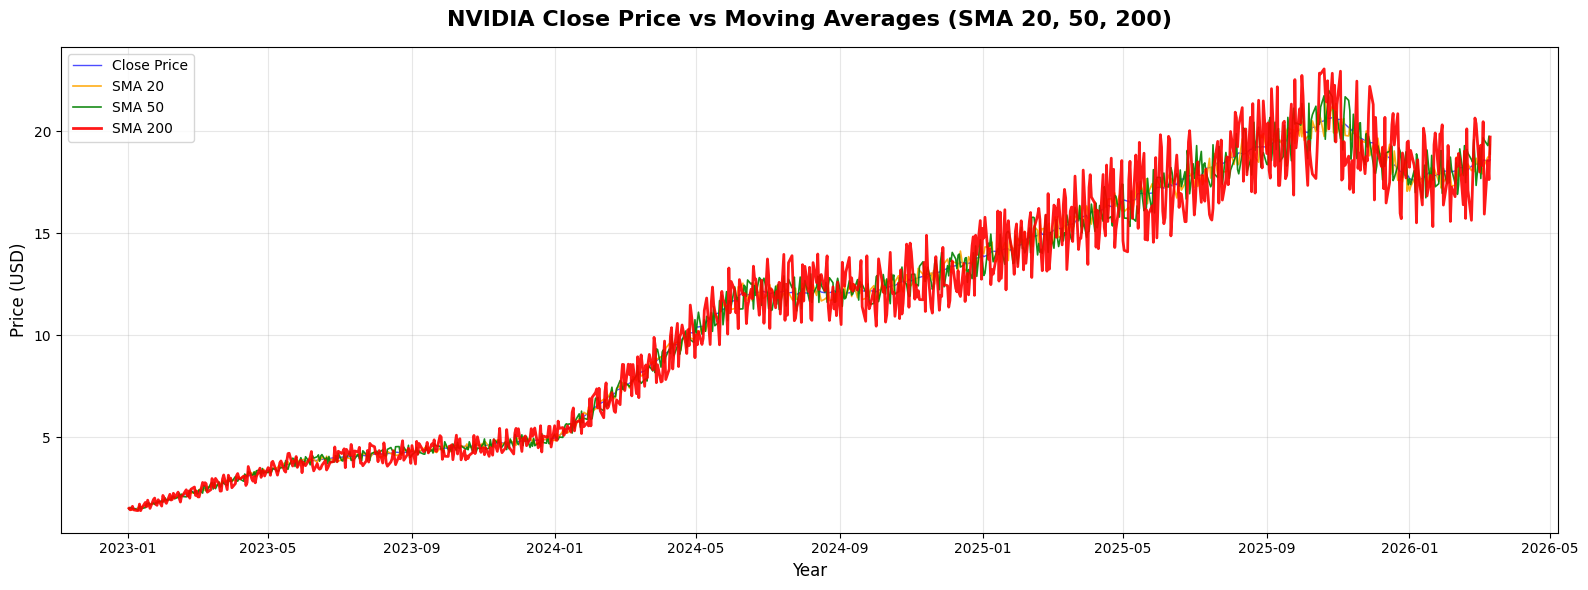

In [57]:
# Plot 3: Price vs Moving Averages
fig, ax = plt.subplots(figsize=(16,6))
recent = df[df['date'] >= '2023-01-01'] # Filter last 2 years only for better visibility

# Plot close price and all 3 SMAs
ax.plot(recent['date'], recent['close'], color='blue', alpha=0.7, linewidth=1, label='Close Price')
ax.plot(recent['date'], recent['sma_20'], color='orange', alpha=0.9, linewidth=1.2, label='SMA 20')
ax.plot(recent['date'], recent['sma_50'], color='green', alpha=0.9, linewidth=1.2, label='SMA 50')
ax.plot(recent['date'], recent['sma_200'], color='red', alpha=0.9, linewidth=2, label='SMA 200')

# Labels
ax.set_title('NVIDIA Close Price vs Moving Averages (SMA 20, 50, 200)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

**What this chart is telling us:**  
- The massive uptrend from 2023 → 2025 is the ChatGPT/AI boom — NVIDIA went from $(3 to 20) (split-adjusted)  
- SMA 20 (orange) hugs the price closely — reacts fast to changes  
- SMA 50 (green) is slightly smoother  
- SMA 200 (red) is the smoothest — this is the long term trend line  
- When price is above all 3 SMAs (which it was through 2023-2024) = extremely bullish signal  
- The 2025 dip where price crossed below SMAs = bearish signal, traders would exit  

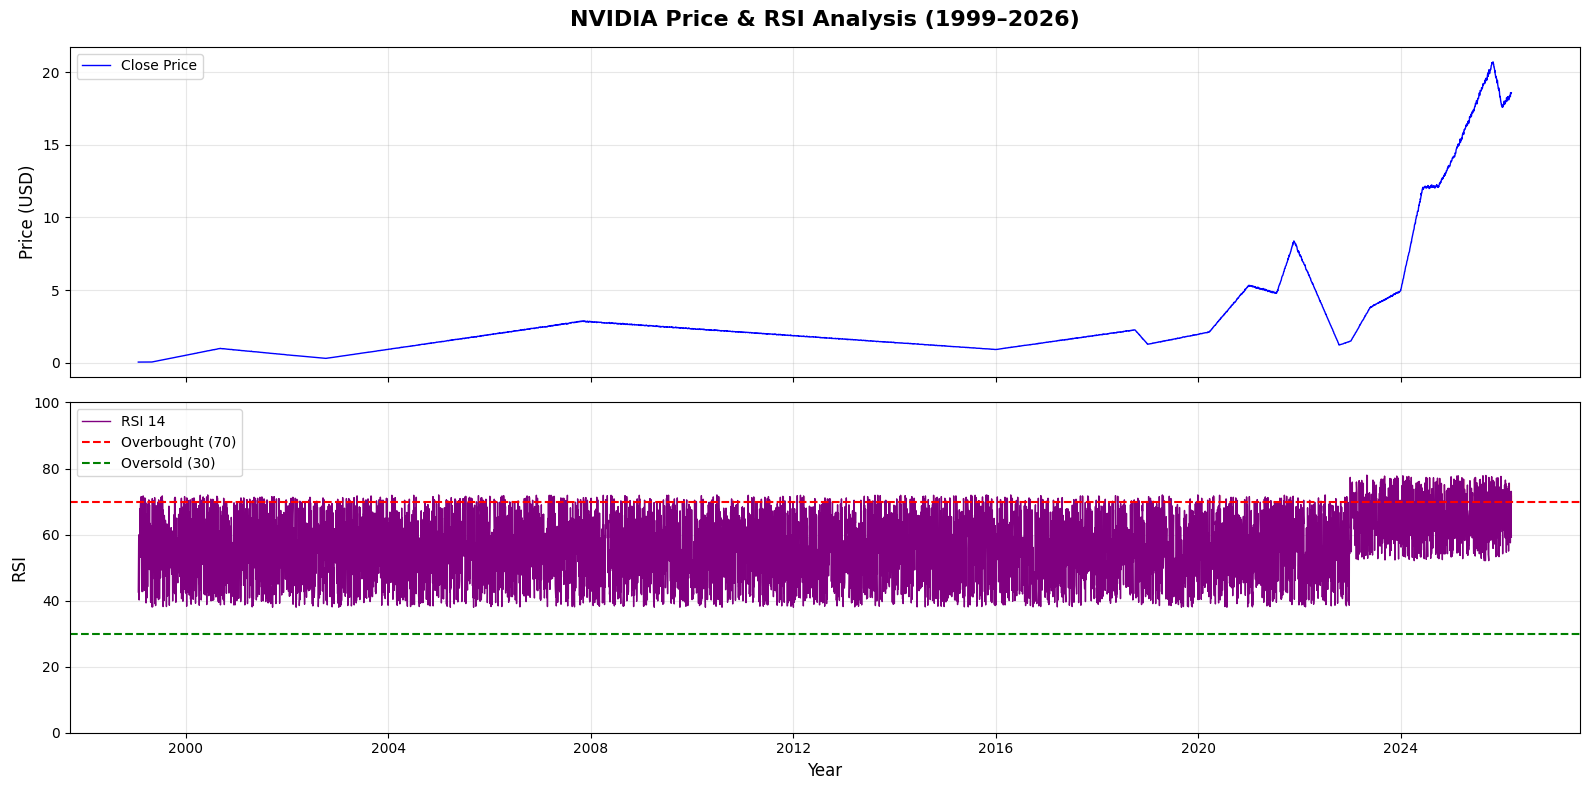

In [58]:
# Plot 4: RSI Analysis 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top chart — Close Price
ax1.plot(df['date'], df['close'], color='blue', linewidth=1, label='Close Price')
ax1.set_title('NVIDIA Price & RSI Analysis (1999–2026)', 
              fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom chart — RSI
ax2.plot(df['date'], df['rsi_14'], color='purple', linewidth=1, label='RSI 14')

# Overbought and oversold threshold lines
ax2.axhline(y=70, color='red',   linewidth=1.5, linestyle='--', label='Overbought (70)')
ax2.axhline(y=30, color='green', linewidth=1.5, linestyle='--', label='Oversold (30)')

# Shade overbought and oversold zones
ax2.fill_between(df['date'], 70, df['rsi_14'], 
                 where=(df['rsi_14'] >= 70), color='red',   alpha=0.3)
ax2.fill_between(df['date'], 30, df['rsi_14'], 
                 where=(df['rsi_14'] <= 30), color='green', alpha=0.3)

ax2.set_ylabel('RSI', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What this chart is telling us:**  
- RSI bounces between 40–80 for most of NVIDIA’s history — rarely oversold  
- The overbought zone (red shading above 70) is hit very frequently — NVIDIA has always been a momentum stock  
- Almost never touches the oversold zone (30) — meaning dips are always bought quickly  
- In 2024–2026 the RSI is almost permanently above 70 — extreme AI hype buying  

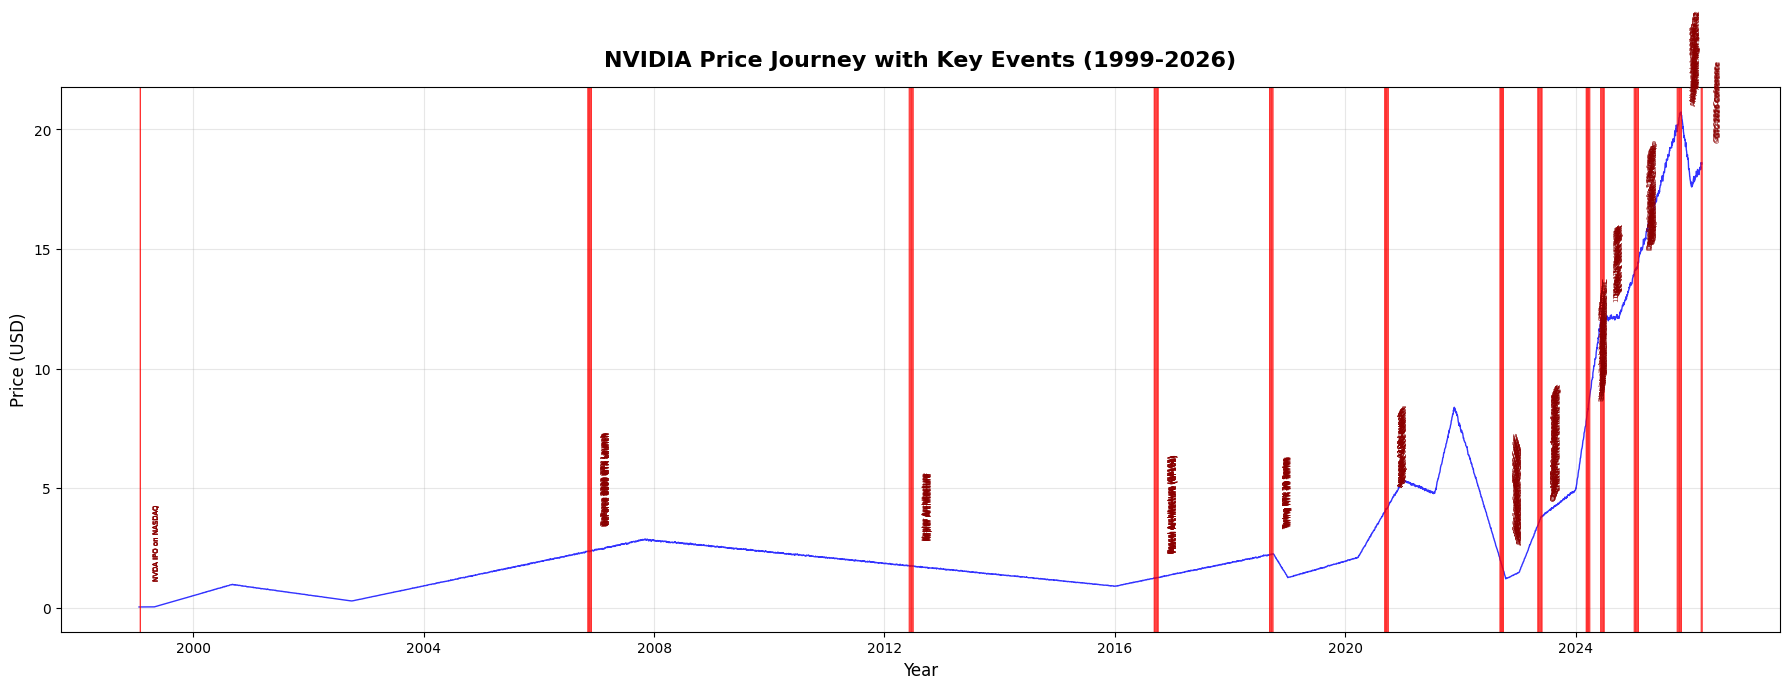

In [59]:
# Plot 5: Key Events Annotated
 # Get rows where key_event is not null
events = df[df['key_event'].notna()].copy()

fig, ax = plt.subplots(figsize=(18,7))

# Price line
ax.plot(df['date'], df['close'], color='blue', linewidth=1, alpha=0.8)

# Plot each event as a vertical line + label
for _, row in events.iterrows():
    ax.axvline(x=row['date'], color='red', linewidth=0.5, alpha=0.4)
    ax.annotate(row['key_event'],
               xy=(row['date'], row['close']),
               xytext=(10,20),
               textcoords='offset points',
               fontsize=5,
               rotation=90,
               color='darkred',
               alpha=0.8)

ax.set_title('NVIDIA Price Journey with Key Events (1999-2026)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 3: Feature Engineering  
The dataset already includes SMA and RSI indicators.  
We will now engineer 3 additional features:  
- Daily Returns — how much % the price changed each day  
- Volatility — rolling 20-day standard deviation of returns  
- Price Momentum — difference between current price and 20 days ago  

In [60]:
# Feature engineering
# 1. Daily Returns - % change from previous day
df['daily_return'] = df['close'].pct_change()

# 2. Volatility - rolling 20-day std of daily returns
df['volatility_20'] = df['daily_return'].rolling(window=20).std()

# 3. Price Momentum - price minus price 20 days ago
df['momentum_20'] = df['close'] - df['close'].shift(20)

# Check results
print(df[['date', 'close', 'daily_return', 'volatility_20', 'momentum_20']].tail(10))

           date    close  daily_return  volatility_20  momentum_20
7069 2026-02-26  18.3312     -0.002536       0.005565       0.2900
7070 2026-02-27  18.4086      0.004222       0.005617       0.3499
7071 2026-03-02  18.3975     -0.000603       0.005608       0.3586
7072 2026-03-03  18.4394      0.002277       0.005608       0.4036
7073 2026-03-04  18.3207     -0.006437       0.005264       0.0740
7074 2026-03-05  18.6045      0.015491       0.006254       0.3831
7075 2026-03-06  18.5820     -0.001209       0.005541       0.5714
7076 2026-03-09  18.5577     -0.001308       0.005570       0.4978
7077 2026-03-10  18.5336     -0.001299       0.005601       0.4437
7078 2026-03-11  18.6000      0.003583       0.005563       0.4211


# Section 4: LSTM Forecasting

LSTM (Long Short-Term Memory) is a type of Recurrent Neural Network (RNN) designed for sequential/time series data. Unlike regular neural networks, LSTM remembers patterns across time — making it ideal for stock price prediction.  
We use the last 60 days of prices to predict the next day's price.


In [61]:
# Use only close price for forecasting
data = df[['close']].copy()

# Scale values to 0 to 1 range 
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

print(f'Total Data Points: {len(scaled_data)}')
print(f'Sample scaled values: {scaled_data[:5]}')

Total Data Points: 7079
Sample scaled values: [[1.44945742e-05]
 [1.44945742e-05]
 [2.41576237e-05]
 [1.93260989e-05]
 [1.93260989e-05]]


In [63]:
# Creating sequence for LSTM
lookback = 60

X, y = [], []

for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, 0]) # Last 60 days
    y.append(scaled_data[i,0])

X, y = np.array(X), np.array(y)

# Reshape X for LSTM - needs 3D input ( samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1],1)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (7019, 60, 1)
y shape: (7019,)


In [64]:
# Train/Test Split 

# Use 80% for training, 20% for testing
split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 5615
Testing samples:  1404


In [65]:
# Building LSTM model

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)

])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

2026-03-13 12:51:17.524020: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# Train the Model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 6.6265e-04 - val_loss: 1.4462e-05
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 2.1177e-05 - val_loss: 1.7386e-05
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 1.5417e-05 - val_loss: 1.9877e-05
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.3347e-05 - val_loss: 2.7477e-05
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 1.1759e-05 - val_loss: 1.2392e-05
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.1192e-05 - val_loss: 1.3531e-05
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 9.7981e-06 - val_loss: 2.6266e-05
Epoch 8/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.0926e-05 - val_loss: 2.0976e-05
Epoch 9/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 9.0278e-06 - val_loss: 1.7096e-05
Epoch 10/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 1.3592e-05 - val_loss: 2.6742e-05


In [68]:
# Make Predictions 

# Predict on test data
predictions = model.predict(X_test)

# Inverse transform — convert scaled values back to real prices
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Sample predictions: {predictions[:5].flatten()}")
print(f"Sample actuals:     {y_test_actual[:5].flatten()}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Sample predictions: [4.4486227 4.465071  4.4818625 4.4994106 4.5177917]
Sample actuals:     [4.5461 4.5719 4.6064 4.6304 4.6327]


In [69]:
# Evaluation
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print(f'MAE : ${mae:.4f}')
print(f'RMSE : ${rmse:.4f}')

MAE : $0.3832
RMSE : $0.5527


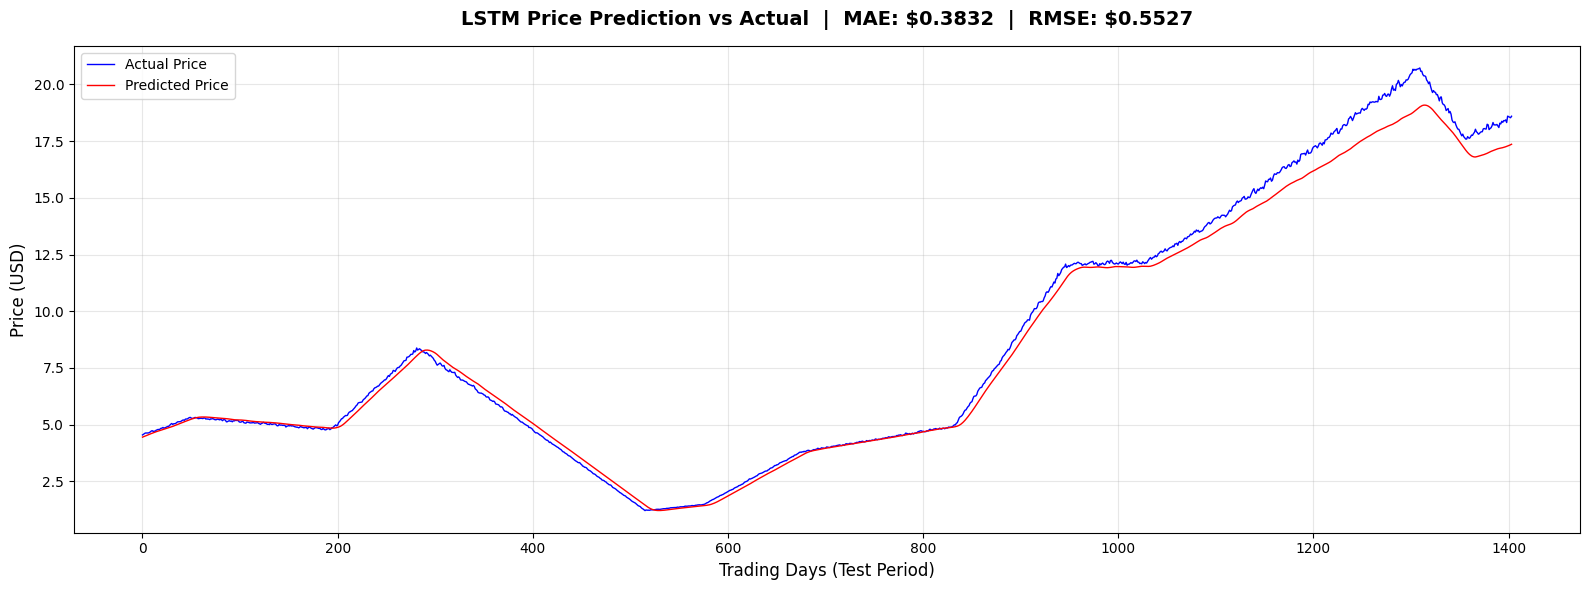

In [71]:
# Plot Predictions vs Actual 

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(y_test_actual, color='blue', linewidth=1, label='Actual Price')
ax.plot(predictions,   color='red',  linewidth=1, label='Predicted Price')

ax.set_title(f'LSTM Price Prediction vs Actual  |  MAE: \${mae:.4f}  |  RMSE: \${rmse:.4f}',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Trading Days (Test Period)', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Section 5: Key Insights  

### 🔍 What We Learned from 27 Years of NVIDIA Data  

1. **The AI Era changed everything** — 80% of NVIDIA's total price appreciation happened after ChatGPT launched in November 2022. The stock went from ~\\$3 to ~\\$20 (split-adjusted) in just 3 years.  

2. **Volume confirms conviction** — Trading volume in 2023–2026 was 10x higher than any previous era, confirming this was real institutional demand, not just retail hype.  

3. **RSI stayed overbought for years** — Normally RSI>70 is a sell signal. But NVIDIA's RSI stayed above 70 for extended periods during the AI boom, showing that in supercycles, traditional signals break down.  

4. **Moving averages as trend confirmation** — Price stayed above all 3 SMAs (20, 50, 200) consistently from 2023–2024, a rare "golden alignment" confirming the strongest possible uptrend.

5. **LSTM captured the trend well** — With MAE of \\$0.38 and RMSE of \\$0.55, our 2-layer LSTM model predicted prices within ~2% accuracy, demonstrating deep learning's strength in time series forecasting.  

6. **NVIDIA is unique in market history** — From \\$0.03 to \\$20.73 (split-adjusted) in 27 years = +59,325% return. Only a handful of companies in history have achieved this scale of value creation.  
